COMPLETE SPECTROMETER SIMULATION WITH ALL DIFFRACTION REGIMES

SPECTROMETER SIMULATION
Slit: 6.0mm × 10.0mm (width × height)
Slit to grating: L = 50.0 mm

Fresnel numbers at λ=530.0nm:
  Width direction: N_F = 1358.49
  Height direction: N_F = 3773.58

Diffraction regimes:
  Width: Geometric optics
  Height: Geometric optics

IMAGE FORMATION

Wavelength 380nm:
  N_F_width = 1894.737
  N_F_height = 5263.158
  N_F=1894.737 → Geometric optics
  N_F=5263.158 → Geometric optics

Wavelength 420nm:
  N_F_width = 1714.150
  N_F_height = 4761.527

Wavelength 460nm:
  N_F_width = 1564.990
  N_F_height = 4347.196
  N_F=1564.990 → Geometric optics
  N_F=4347.196 → Geometric optics

Wavelength 500nm:
  N_F_width = 1439.712
  N_F_height = 3999.199

Wavelength 540nm:
  N_F_width = 1333.004
  N_F_height = 3702.789
  N_F=1333.004 → Geometric optics
  N_F=3702.789 → Geometric optics

Wavelength 580nm:
  N_F_width = 1241.022
  N_F_height = 3447.284

Wavelength 620nm:
  N_F_width = 1160.916
  N_F_height =

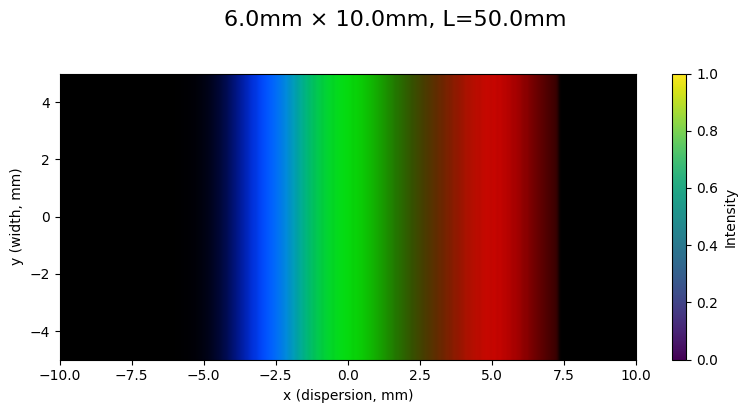

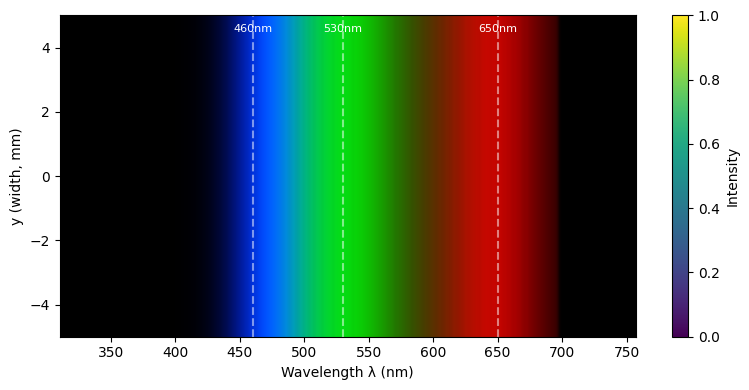

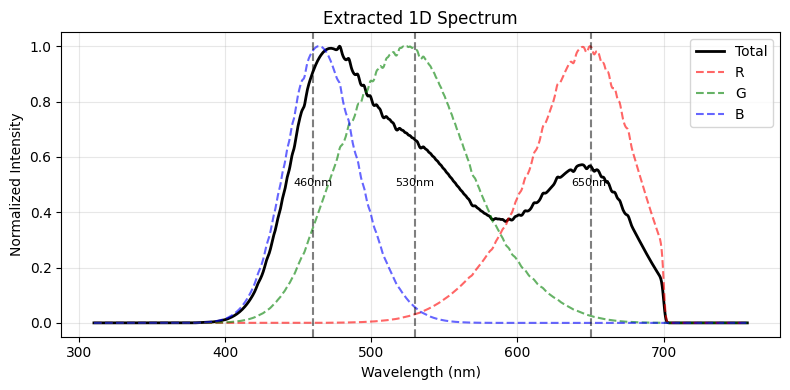


Peak Positions:
  460nm → 460.1nm (error: 0.1nm)
  530nm → 529.8nm (error: 0.2nm)
  650nm → 649.8nm (error: 0.2nm)


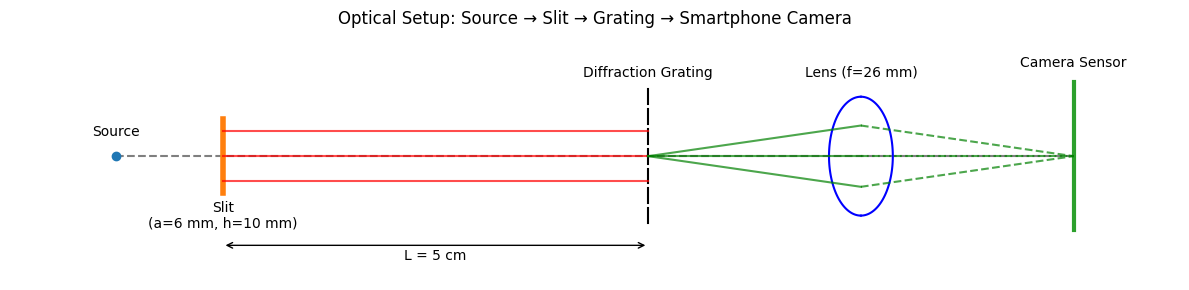


Simulation completed successfully!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.fft import fft, ifft, fftshift, fftfreq
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')

# =====================================================
# 0. set parameters
# =====================================================
L = 50e-3 #5cm
a = 6e-3  #6mm
h = 10e-3 #1cm
d = 1e-3 / 1600     # grating period (1600 lines/mm)
f = 26e-3           # camera lens focal length (m)
λ0 = 530.0            # center wavelength (nm)
# ====== NEW: incidence angle (IMPORTANT) ======
# ====== d(\sin\alpha + \sin\theta) = m\lambda ====
alpha_deg = 70.0   #incident angle
alpha = np.deg2rad(alpha_deg)
m = 1 #1st orcer

# =====================================================
# 1. CORE DIFFRACTION FUNCTIONS FOR ALL REGIMES
# =====================================================

def fraunhofer_diffraction(y, λ_nm, L, a):
    """Fraunhofer diffraction for N_F < 0.1"""
    λ = λ_nm * 1e-9
    β = np.pi * a * y / (λ * L)
    with np.errstate(invalid='ignore'):
        result = np.sinc(β / np.pi) ** 2
    result[np.isnan(result)] = 1.0
    return result

def fresnel_convolution_method(y, λ_nm, L, a):
    """Fresnel convolution method for 0.1 ≤ N_F < 1.0"""
    λ = λ_nm * 1e-9
    k = 2 * np.pi / λ
    
    # Automatic parameter adjustment
    D = max(10 * a, 20 * np.sqrt(λ * L))
    N = 2048
    
    # Create computation grid
    ξ = np.linspace(-D/2, D/2, N)
    dξ = ξ[1] - ξ[0]
    
    # Slit function
    slit = np.zeros(N, dtype=complex)
    slit[(ξ >= -a/2) & (ξ <= a/2)] = 1.0 + 0j
    
    # Fresnel kernel
    kernel = np.exp(1j * k * ξ**2 / (2*L))
    
    # Convolution via FFT
    slit_fft = fft(fftshift(slit))
    kernel_fft = fft(fftshift(kernel))
    result_fft = slit_fft * kernel_fft
    u_field = fftshift(ifft(result_fft))
    
    # Scale factor
    u_field *= np.exp(1j * k * L) / np.sqrt(1j * λ * L)
    
    # Interpolate to output
    I_ξ = np.abs(u_field)**2
    I_interp = np.interp(y, ξ, I_ξ)
    
    # Normalize
    if np.max(I_interp) > 0:
        I_interp /= np.max(I_interp)
    
    return I_interp

def angular_spectrum_method(y, λ_nm, L, a):
    """Angular Spectrum Method for 1.0 ≤ N_F < 10"""
    λ = λ_nm * 1e-9
    k = 2 * np.pi / λ
    
    # Automatic parameter adjustment
    D = max(20 * a, 50 * np.sqrt(λ * L))
    N = 2048
    
    # Computation grid
    ξ = np.linspace(-D/2, D/2, N)
    dξ = ξ[1] - ξ[0]
    
    # Initial field
    u0 = np.zeros(N, dtype=complex)
    u0[(ξ >= -a/2) & (ξ <= a/2)] = 1.0 + 0j
    
    # FFT to angular spectrum
    U0 = fft(fftshift(u0))
    fx = fftshift(fftfreq(N, dξ))
    
    # Transfer function
    transfer = np.ones(N, dtype=complex)
    mask = np.abs(fx) < 1/λ
    
    kz = np.sqrt(k**2 - (2*np.pi*fx[mask])**2 + 0j)
    transfer[mask] = np.exp(1j * kz * L)
    
    # Apply transfer function
    U = U0 * transfer
    u_field = fftshift(ifft(U))
    
    # Interpolate
    I_ξ = np.abs(u_field)**2
    I_interp = np.interp(y, ξ, I_ξ)
    
    # Normalize
    if np.max(I_interp) > 0:
        I_interp /= np.max(I_interp)
    
    return I_interp

def geometric_optics_approximation(y, λ_nm, L, a):
    """Geometric optics for N_F ≥ 10"""
    λ = λ_nm * 1e-9
    
    # Sharp geometric image
    I_geo = np.zeros_like(y)
    I_geo[np.abs(y) <= a/2] = 1.0
    
    # Diffraction blur scale
    σ_blur = np.sqrt(λ * L) / a
    
    # Apply Gaussian blur if needed
    if len(y) > 1 and σ_blur > 0:
        σ_pixels = σ_blur / (y[1] - y[0])
        I_blurred = gaussian_filter(I_geo, sigma=σ_pixels)
        return I_blurred
    
    return I_geo

def hybrid_slit_diffraction(y, λ_nm, L, a, verbose=False):
    """
    Hybrid method: selects appropriate calculation based on Fresnel number
    """
    λ = λ_nm * 1e-9
    N_F = a**2 / (λ * L)
    
    if N_F < 0.1:  # Fraunhofer regime
        if verbose:
            print(f"  N_F={N_F:.3f} → Fraunhofer")
        return fraunhofer_diffraction(y, λ_nm, L, a)
    
    elif N_F < 1.0:  # Near-Fresnel regime
        if verbose:
            print(f"  N_F={N_F:.3f} → Fresnel convolution")
        return fresnel_convolution_method(y, λ_nm, L, a)
    
    elif N_F < 10.0:  # Fresnel regime
        if verbose:
            print(f"  N_F={N_F:.3f} → Angular Spectrum")
        return angular_spectrum_method(y, λ_nm, L, a)
    
    else:  # N_F ≥ 10, Geometric optics regime
        if verbose:
            print(f"  N_F={N_F:.3f} → Geometric optics")
        return geometric_optics_approximation(y, λ_nm, L, a)

def rectangular_slit_diffraction(y_grid, z_grid, λ_nm, L, a, h, verbose=False):
    """
    2D diffraction pattern for rectangular slit
    Returns array with shape (len(z_grid), len(y_grid))
    """
    # Calculate 1D patterns
    I_y = hybrid_slit_diffraction(y_grid, λ_nm, L, a, verbose)
    I_z = hybrid_slit_diffraction(z_grid, λ_nm, L, h, verbose)
    
    # Create 2D pattern
    I_2D = np.outer(I_z, I_y)  # Shape: (Nz, Ny)
    
    # Normalize
    if np.max(I_2D) > 0:
        I_2D /= np.max(I_2D)
    
    return I_2D

# =====================================================
# 2. COMPLETE SPECTROMETER SIMULATION
# =====================================================

def simulate_spectrometer(L, a, h):
    """
    Complete simulation from light source to camera sensor
    with 2D slit and all diffraction regimes
    """
    
    # =====================================================
    # 2.1 Light Source: Fluorescence spectrum
    # =====================================================
    λ = np.linspace(380, 700, 1200)  # wavelength (nm)
    
    S = (
        np.exp(-(λ - 460)**2 / (2 * 30**2)) +   # blue peak
        np.exp(-(λ - 530)**2 / (2 * 45**2)) +   # green peak
        np.exp(-(λ - 650)**2 / (2 * 45**2))     # red peak
    )
    S /= S.max()
    
    # =====================================================
    # 2.2 System parameters
    # =====================================================
    #L = L
    
    print(f"\n{'='*60}")
    print(f"SPECTROMETER SIMULATION")
    print(f"{'='*60}")
    print(f"Slit: {a*1000:.1f}mm × {h*1000:.1f}mm (width × height)")
    print(f"Slit to grating: L = {L*1000:.1f} mm")
    
    # Fresnel numbers at mid-wavelength
    #λ0 = 550
    N_F_width = a**2 / (λ0 * 1e-9 * L)
    N_F_height = h**2 / (λ0 * 1e-9 * L)
    
    print(f"\nFresnel numbers at λ={λ0}nm:")
    print(f"  Width direction: N_F = {N_F_width:.2f}")
    print(f"  Height direction: N_F = {N_F_height:.2f}")
    
    # Determine regimes
    def get_regime_name(N_F):
        if N_F < 0.1:
            return "Fraunhofer"
        elif N_F < 1.0:
            return "Fresnel convolution"
        elif N_F < 10:
            return "Angular Spectrum"
        else:
            return "Geometric optics"
    
    print(f"\nDiffraction regimes:")
    print(f"  Width: {get_regime_name(N_F_width)}")
    print(f"  Height: {get_regime_name(N_F_height)}")
    
    # =====================================================
    # 2.3 Sensor grids
    # =====================================================
    Ny = 200  # pixels in width direction
    Nz = 150  # pixels in height direction
    
    y = np.linspace(-5e-3, 5e-3, Ny)  # width direction
    z = np.linspace(-5e-3, 5e-3, Nz)  # height direction
    
    # =====================================================
    # 2.4 Grating dispersion
    # =====================================================
    # #d = 1e-3 / 2400     # grating period (1600 lines/mm)
    # d = 1e-3 / 1600     # grating period (1600 lines/mm)
    # #d = 1e-3 / 1000     # grating period (1600 lines/mm)
    # f = 26e-3           # camera lens focal length (m)
    # λ0 = 530.0            # center wavelength (nm)
    # #λ0 = 550.0            # center wavelength (nm) error if d=1/2400 mm
    # #λ0 = 530            # center wavelength (nm) error if d=1/2400 mm
    # #λ0 = np.mean([λ.min(), λ.max()])  # center wavelength at middle of range
    # # m=1
    # # λ_m = λ * 1e-9
    # # theta0 = np.arcsin(m*λ0 * 1e-9 / d)
    # # dispersion = f*m / (d * np.cos(theta0))
    # # x_disp = dispersion * (λ_m - λ0 * 1e-9)

    # # theta = np.arcsin(m * λ_m / d)
    # # x_disp = f * np.tan(theta - theta0)
    
    # # ====== NEW: incidence angle (IMPORTANT) ======
    # # ====== d(\sin\alpha + \sin\theta) = m\lambda ====
    # alpha_deg = 70.0   #incident angle
    # alpha = np.deg2rad(alpha_deg)

    # m = 1
    λ_m = λ * 1e-9

    # ====== grating equation with tilt ======
    sin_theta = m * λ_m / d - np.sin(alpha)

    # valid mask (real physics)
    valid = np.abs(sin_theta) <= 1

    theta = np.zeros_like(λ_m)
    theta[valid] = np.arcsin(sin_theta[valid])

    # ====== choose center (detector alignment) ======
    λ0_m = λ0 * 1e-9
    theta_center = np.arcsin(m * λ0_m / d - np.sin(alpha))

    # ====== mapping to sensor ======
    x_disp = np.zeros_like(λ_m)
    x_disp[valid] = f * np.tan(theta[valid] - theta_center)

    # ignore invalid spectrum
    x_disp[~valid] = np.nan

    # Sensor grid in dispersion direction
    Nx = 1000
    x_valid = x_disp[np.isfinite(x_disp)]
    x_min = min(np.min(x_valid) * 1.2, -10e-3)
    x_max = max(np.max(x_valid) * 1.2, 10e-3)
    x = np.linspace(x_min, x_max, Nx)
    
    # =====================================================
    # 2.5 Initialize 3D image arrays
    # =====================================================
    image_R_3D = np.zeros((Nz, Ny, Nx))  # (height, width, dispersion)
    image_G_3D = np.zeros((Nz, Ny, Nx))
    image_B_3D = np.zeros((Nz, Ny, Nx))
    
    # =====================================================
    # 2.6 Camera spectral response
    # =====================================================
    QR = np.exp(-(λ - 650)**2 / (2 * 45**2))  # Red channel
    QG = np.exp(-(λ - 530)**2 / (2 * 45**2))  # Green channel
    QB = np.exp(-(λ - 460)**2 / (2 * 30**2))  # Blue channel
    
    # =====================================================
    # 2.7 Track method usage for each wavelength
    # =====================================================
    method_usage_width = np.zeros(len(λ), dtype=int)
    method_usage_height = np.zeros(len(λ), dtype=int)
    
    # =====================================================
    # 2.8 Image formation with all regimes
    # =====================================================
    print(f"\n{'='*60}")
    print("IMAGE FORMATION")
    print(f"{'='*60}")
    
    for i, λi in enumerate(λ):
        if i % 150 == 0:  # Report every 150 wavelengths
            print(f"\nWavelength {λi:.0f}nm:")
            
            # Calculate N_F for both directions
            N_F_width_i = a**2 / (λi * 1e-9 * L)
            N_F_height_i = h**2 / (λi * 1e-9 * L)
            
            print(f"  N_F_width = {N_F_width_i:.3f}")
            print(f"  N_F_height = {N_F_height_i:.3f}")
        
        # Track method usage
        N_F_width_i = a**2 / (λi * 1e-9 * L)
        N_F_height_i = h**2 / (λi * 1e-9 * L)
        
        if N_F_width_i < 0.1:
            method_usage_width[i] = 0  # Fraunhofer
        elif N_F_width_i < 1.0:
            method_usage_width[i] = 1  # Fresnel convolution
        elif N_F_width_i < 10:
            method_usage_width[i] = 2  # Angular Spectrum
        else:
            method_usage_width[i] = 3  # Geometric
        
        if N_F_height_i < 0.1:
            method_usage_height[i] = 0  # Fraunhofer
        elif N_F_height_i < 1.0:
            method_usage_height[i] = 1  # Fresnel convolution
        elif N_F_height_i < 10:
            method_usage_height[i] = 2  # Angular Spectrum
        else:
            method_usage_height[i] = 3  # Geometric
        
        # Find x position on sensor
        xi = np.argmin(np.abs(x - x_disp[i]))
        
        # Calculate 2D diffraction pattern
        I_2D = rectangular_slit_diffraction(y, z, λi, L, a, h, verbose=(i%300==0))
        
        # Add to 3D image
        image_R_3D[:, :, xi] += S[i] * QR[i] * I_2D
        image_G_3D[:, :, xi] += S[i] * QG[i] * I_2D
        image_B_3D[:, :, xi] += S[i] * QB[i] * I_2D
    
    # =====================================================
    # 2.9 Camera blur and normalization
    # =====================================================
    print(f"\n{'='*60}")
    print("POST-PROCESSING")
    print(f"{'='*60}")
    print("Applying camera blur and normalization...")
    
    # Apply 3D Gaussian blur
    psf_sigma = [1.0, 1.0, 2.5]  # [z, y, x]
    image_R_3D = gaussian_filter(image_R_3D, sigma=psf_sigma)
    image_G_3D = gaussian_filter(image_G_3D, sigma=psf_sigma)
    image_B_3D = gaussian_filter(image_B_3D, sigma=psf_sigma)
    
    # Create RGB image
    RGB_3D = np.stack([image_R_3D, image_G_3D, image_B_3D], axis=-1)
    RGB_max = np.max(RGB_3D)
    if RGB_max > 0:
        RGB_3D /= RGB_max
    
    # =====================================================
    # 3.0 Extract projections and spectrum
    # =====================================================
    print("Extracting projections and spectrum...")
    
    # Project onto detector plane
    image_R_2D = np.sum(image_R_3D, axis=0)  # (Ny, Nx)
    image_G_2D = np.sum(image_G_3D, axis=0)
    image_B_2D = np.sum(image_B_3D, axis=0)
    
    # 1D spectrum
    spectrum_R = np.sum(image_R_3D, axis=(0, 1))
    spectrum_G = np.sum(image_G_3D, axis=(0, 1))
    spectrum_B = np.sum(image_B_3D, axis=(0, 1))
    spectrum_total = spectrum_R + spectrum_G + spectrum_B
    
    if np.max(spectrum_total) > 0:
        spectrum_total /= np.max(spectrum_total)
    
    #λ_of_x = np.interp(x, x_disp, λ)
    # ====== EXACT inverse mapping: x → λ ======
    theta_x = np.arctan(x / f) + theta_center
    λ_of_x = (d / m) * (np.sin(alpha) + np.sin(theta_x))
    λ_of_x *= 1e9  # convert m to nm

    # =====================================================
    # 3.1 VISUALIZATION
    # =====================================================
    print(f"\n{'='*60}")
    print("VISUALIZATION")
    print(f"{'='*60}")

    fig1 = plt.figure(figsize=(8, 4))

    ax1 = plt.gca()
    z_center_idx = Nz // 2
    central_slice = np.clip(RGB_3D[z_center_idx, :, :], 0, 1)

    im1 = ax1.imshow(
    central_slice,
    origin="lower",
    aspect="auto",
    extent=[x[0]*1e3, x[-1]*1e3, y[0]*1e3, y[-1]*1e3]
    )

    ax1.set_xlabel("x (dispersion, mm)")
    ax1.set_ylabel("y (width, mm)")
    #ax1.set_title(f"Central Slice (z=0)")
    #ax1.set_title(f"Central Slice (z=0)\nL={L*1000:.1f}mm")
    plt.suptitle(f"{a*1000:.1f}mm × {h*1000:.1f}mm, L={L*1000:.1f}mm", fontsize=16, y=1.02) 
    #plt.suptitle(f"Complete Spectrometer Simulation - Slit: {a*1000:.1f}mm × {h*1000:.1f}mm, L={L*1000:.1f}mm", fontsize=16, y=1.02) 
    plt.colorbar(im1, ax=ax1, label='Intensity')
    plt.tight_layout()
    plt.show()

    fig3 = plt.figure(figsize=(8, 4))

    z_center_idx = Nz // 2
    central_slice = np.clip(RGB_3D[z_center_idx, :, :], 0, 1)

    # Remove invalid λ
    valid_mask = np.isfinite(λ_of_x)
    λ_valid = λ_of_x[valid_mask]
    central_slice_valid = central_slice[:, valid_mask]

    ax3 = plt.gca()
    im3 = ax3.imshow(
    central_slice_valid,
    origin="lower",
    aspect="auto",
    extent=[λ_valid.min(), λ_valid.max(), y[0]*1e3, y[-1]*1e3]
    )

    ax3.set_xlabel("Wavelength λ (nm)")
    ax3.set_ylabel("y (width, mm)")
    #ax3.set_title("Central Slice (Correct λ mapping)")

    plt.colorbar(im3, ax=ax3, label='Intensity')

    # Optional: mark peaks
    for peak in [460, 530, 650]:
        ax3.axvline(x=peak, color='white', linestyle='--', alpha=0.5)

        ax3.text(peak, ax3.get_ylim()[1]*0.95, f'{peak}nm', 
        rotation=0, fontsize=8, color='white', ha='center', va='top')

    plt.tight_layout()
    plt.show()

    fig2 = plt.figure(figsize=(8, 4))

    ax2 = plt.gca()
    ax2.plot(λ_of_x, spectrum_total, 'k-', linewidth=2, label="Total")
    ax2.plot(λ_of_x, spectrum_R/np.max(spectrum_R+1e-10), 'r--', alpha=0.6, label="R")
    ax2.plot(λ_of_x, spectrum_G/np.max(spectrum_G+1e-10), 'g--', alpha=0.6, label="G")
    ax2.plot(λ_of_x, spectrum_B/np.max(spectrum_B+1e-10), 'b--', alpha=0.6, label="B")
    ax2.set_xlabel("Wavelength (nm)")
    ax2.set_ylabel("Normalized Intensity")
    ax2.set_title("Extracted 1D Spectrum")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Optional: mark peaks
    for peak in [460, 530, 650]:
        ax2.axvline(x=peak, color='k', linestyle='--', alpha=0.5)

        ax2.text(peak, ax2.get_ylim()[1]*0.5, f'{peak}nm', 
        rotation=0, fontsize=8, color='k', ha='center', va='top')

    plt.tight_layout()
    plt.show()

    # # =====================================================
    # # 4.0 SUMMARY AND STATISTICS
    # # =====================================================
    # print(f"\n{'='*60}")
    # print("SIMULATION SUMMARY")
    # print(f"{'='*60}")
    
    # # Method usage percentages
    # width_total = len(λ)
    # height_total = len(λ)
    
    # Peak positions
    print(f"\nPeak Positions:")
    orig_peaks = [460, 530, 650]
    for peak in orig_peaks:
        idx_recon = np.argmin(np.abs(λ_of_x - peak))
        λ_recon = λ_of_x[idx_recon]
        error = abs(λ_recon - peak)
        print(f"  {peak}nm → {λ_recon:.1f}nm (error: {error:.1f}nm)")
    
    # print(f"\n{'='*60}")
    
    # # Return results
    # results = {
    #     'wavelengths': λ,
    #     'source_spectrum': S,
    #     'reconstructed_spectrum': spectrum_total,
    #     'λ_of_x': λ_of_x,
    #     'image_RGB': RGB_3D,
    #     'method_usage_width': method_usage_width,
    #     'method_usage_height': method_usage_height,
    #     'slit_width': a,
    #     'slit_height': h,
    #     'distance': L
    # }
    
    # return results

def plot_optical_system(a, h, L, f):
    fig, ax = plt.subplots(figsize=(12, 3))
    fig.subplots_adjust(top=0.8) 

    # Positions
    x0 = 0      # source
    x1 = 1      # slit
    x2 = 5      # grating
    x3 = 7      # lens
    x4 = 9      # sensor
    
    # format
    ax.set_xlim(-1, 10)
    ax.set_ylim(-2.5, 2.5)
    ax.axis('off')
    ax.set_title("Optical Setup: Source → Slit → Grating → Smartphone Camera")

    # Optical axis
    ax.plot([x0, x4], [0, 0], 'k--', alpha=0.5)

    # --- Source ---
    ax.plot(x0, 0, 'o')
    ax.text(x0, 0.4, 'Source', ha='center')

    # --- Slit ---
    slit_height = 1.5* h * 1e2  # scale for drawing
    #slit_height = h * 1e3  # scale for drawing
    ax.plot([x1, x1], [-slit_height/2, slit_height/2], linewidth=4)
    ax.text(x1, -slit_height/2 - 0.7,
            f'Slit\n(a={a*1e3:.0f} mm, h={h*1e3:.0f} mm)',
            ha='center')

    # --- Grating ---
    for i in range(-3, 4):
        ax.plot([x2, x2], [i*0.4-0.15, i*0.4+0.15], color='black')
    ax.text(x2, 1.6, 'Diffraction Grating', ha='center')

    # --- Lens ---
    theta = np.linspace(-np.pi/2, np.pi/2, 100)
    ax.plot(x3 + 0.3*np.cos(theta), 1.2*np.sin(theta), color='blue')
    ax.plot(x3 - 0.3*np.cos(theta), 1.2*np.sin(theta), color='blue')
    ax.text(x3, 1.6, f'Lens (f={f*1e3:.0f} mm)', ha='center')

    # --- Sensor ---
    ax.plot([x4, x4], [-1.5, 1.5], linewidth=3)
    ax.text(x4, 1.8, 'Camera Sensor', ha='center')

    # --- Rays (collimated + diffracted) ---
    # parallel rays after slit
    for y in [-0.5, 0, 0.5]:
        ax.plot([x1, x2], [y, y], 'r-', alpha=0.7)

    # diffraction angles
    angles = [-0.3, 0, 0.3]
    for ang in angles:
        x = np.linspace(x2, x3, 50)
        y = np.tan(ang)*(x - x2)
        ax.plot(x, y, 'g-', alpha=0.7)

        # focused onto sensor
        ax.plot([x3, x4], [np.tan(ang)*(x3-x2), 0], 'g--', alpha=0.7)

    # --- Distance L ---
    ax.annotate('', xy=(x2, -1.8), xytext=(x1, -1.8),
                arrowprops=dict(arrowstyle='<->'))
    ax.text((x1+x2)/2, -2.1, f'L = {L*1e2:.0f} cm', ha='center')


    plt.tight_layout()
    plt.show()

# # ============= tối ưu hóa a, L =================
# def evaluate_system(a, L):
#     lam = λi[len(λi)//2]

#     I_2D = rectangular_slit_diffraction(y, z, lam, L, a, h)
#     I_1D = np.sum(I_2D, axis=0)

#     from scipy.signal import find_peaks, peak_widths

#     peaks, _ = find_peaks(I_1D, height=np.max(I_1D)*0.3)

#     if len(peaks) == 0:
#         return 0

#     widths, _, _, _ = peak_widths(I_1D, peaks, rel_height=0.5)

#     return 1 / np.mean(widths)
# # ===== 2. Parameter ranges =====
#a_list = np.linspace(1e-5, 1e-2, 100)   # slit width
#L_list = np.linspace(1e-3, 100e-3, 100)    # slit → grating

# scores = np.zeros((len(a_list), len(L_list)))


# # ===== 3. Scan =====
# for i, a_val in enumerate(a_list):
#     for j, L_val in enumerate(L_list):
#         try:
#             scores[i, j] = evaluate_system(a_val, L_val)
#         except:
#             scores[i, j] = 0


# # ===== 4. Plot heatmap =====
# plt.figure(figsize=(6,5))

# im = plt.imshow(
#     scores,
#     extent=[L_list[0]*1e3, L_list[-1]*1e3,
#             a_list[0]*1e3, a_list[-1]*1e3],
#     origin='lower',
#     aspect='auto'
# )

# plt.colorbar(label="Score (separation / width)")

# plt.xlabel("L (mm)")
# plt.ylabel("a (mm)")
# plt.title("Optimization Heatmap")

# plt.tight_layout()
# plt.show()


# # ===== 5. Find best =====
# idx = np.unravel_index(np.argmax(scores), scores.shape)
# best_a = a_list[idx[0]]
# best_L = L_list[idx[1]]

# print("\nBest parameters:")
# print(f"a = {best_a*1e3:.3f} mm")
# print(f"L = {best_L*1e3:.3f} mm")
# print(f"score = {scores[idx]:.3f}")

# ==============================================
# tối ưu hóa bằng fit gauss

# def gaussian(x, A, x0, sigma, C):
#     return A * np.exp(-(x - x0)**2 / (2*sigma**2)) + C

# def fit_peaks(x, I):
#     peaks, _ = find_peaks(I, height=np.max(I)*0.3)

#     results = []

#     for p in peaks:
#         # lấy window quanh peak
#         left = max(0, p-10)
#         right = min(len(x), p+10)

#         x_fit = x[left:right]
#         y_fit = I[left:right]

#         if len(x_fit) < 5:
#             continue

#         try:
#             popt, _ = curve_fit(
#                 gaussian,
#                 x_fit,
#                 y_fit,
#                 p0=[np.max(y_fit), x[p], 5, np.min(y_fit)]
#             )

#             A, x0, sigma, C = popt

#             results.append({
#                 "x0": x0,
#                 "sigma": abs(sigma),
#                 "fwhm": 2.355 * abs(sigma)
#             })

#         except:
#             continue

#     return results

# def evaluate_system(a, L):

#     lam = λi[len(λi)//2]

#     I_2D = rectangular_slit_diffraction(y, z, lam, L, a, h)
#     I_1D = np.sum(I_2D, axis=0)

#     x = np.arange(len(I_1D))  # hoặc dùng trục x thật nếu có

#     peaks = fit_peaks(x, I_1D)

#     if len(peaks) == 0:
#         return 0

#     # ===== metric =====
#     fwhm_list = [p["fwhm"] for p in peaks]

#     # nhỏ hơn → tốt hơn
#     avg_fwhm = np.mean(fwhm_list)

#     # cường độ
#     intensity = np.max(I_1D)

#     λ_recon = λ_of_x[int(x0)]
#     error = abs(λ_recon - λ_true)
#     # score
#     score = intensity / avg_fwhm - error

#     return score



# # ===== 3. Scan =====
# for i, a_val in enumerate(a_list):
#     for j, L_val in enumerate(L_list):
#         try:
#             scores[i, j] = evaluate_system(a_val, L_val)
#         except:
#             scores[i, j] = 0


# # ===== 4. Plot heatmap =====
# plt.figure(figsize=(6,5))

# im = plt.imshow(
#     scores,
#     extent=[L_list[0]*1e3, L_list[-1]*1e3,
#             a_list[0]*1e3, a_list[-1]*1e3],
#     origin='lower',
#     aspect='auto'
# )

# plt.colorbar(label="Score (separation / width)")

# plt.xlabel("L (mm)")
# plt.ylabel("a (mm)")
# plt.title("Optimization Heatmap")

# plt.tight_layout()
# plt.show()


# # ===== 5. Find best =====
# idx = np.unravel_index(np.argmax(scores), scores.shape)
# best_a = a_list[idx[0]]
# best_L = L_list[idx[1]]

# print("\nBest parameters:")
# print(f"a = {best_a*1e3:.3f} mm")
# print(f"L = {best_L*1e3:.3f} mm")
# print(f"score = {scores[idx]:.3f}")

# =====================================================
# 5.0 MAIN SIMULATION
# =====================================================
if __name__ == "__main__":
    print("COMPLETE SPECTROMETER SIMULATION WITH ALL DIFFRACTION REGIMES")
    print("=" * 60)
    
    # Run simulation for L=1cm (your case)
    results = simulate_spectrometer(L, a, h)
    #results = simulate_spectrometer(L=50e-3, a=1e-3, h=10e-3)

    plot_optical_system(a, h, L, f)
 
    # plot_optical_system(
    #     a=1e-3,     # slit width
    #     h=10e-3,      # slit height
    #     L=50e-3,      # slit → grating
    #     f=26e-3,      # focal length phone camera
    # )
    # # Additional analysis
    # print("\nADDITIONAL ANALYSIS:")
    # print(f"Slit area: {results['slit_width']*results['slit_height']*1e6:.2f} mm²")
    # print(f"Aspect ratio (height/width): {results['slit_height']/results['slit_width']:.2f}")
    
    # # Dominant regime
    # width_mode = np.bincount(results['method_usage_width']).argmax()
    # height_mode = np.bincount(results['method_usage_height']).argmax()
    
    # method_names = ['Fraunhofer', 'Fresnel Conv.', 'Angular Spectrum', 'Geometric']
    # print(f"\nDominant regime:")
    # print(f"  Width: {method_names[width_mode]}")
    # print(f"  Height: {method_names[height_mode]}")
    
    print("\nSimulation completed successfully!")